In [1]:
from src import *

In [13]:

path   =  0.5
sigmaq = 1


In [3]:
log_target = lambda x: log_target_path(x, path)
ri = lambda: initial_distribution(log_target, mean_init=-1, sigma_init=2.0)
sk = lambda x, f: MH_kernel(x, f, sigma_proposal=sigmaq, log_target=log_target)
ck = lambda x1, x2, f1, f2: MH_coupled_kernel(x1, x2, f1, f2, sigma_proposal=sigmaq, log_target=log_target)


In [5]:
res = coupled_chain(sk, ck, ri, k=1, lag=2, max_iterations=1000)

In [19]:
x_1, f_1 = initial_distribution(log_target, mean_init=-1, sigma_init=2.0)
x_2, f_2 = initial_distribution(log_target, mean_init=-1, sigma_init=2.0)

nx_1, nx_2, _, _ =MH_coupled_kernel(x_1, x_2, f_1, f_2, sigma_proposal=sigmaq, log_target=log_target)

In [20]:
nx_1, nx_2

(array([-2.42997973]), array([-11.81236023]))

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_coupling(niterations, path, sigmaq):

    # Initialisation
    x_1, f_1 = initial_distribution(log_target, mean_init=-1, sigma_init=2.0)
    x_2, f_2 = initial_distribution(log_target, mean_init=-1, sigma_init=2.0)

    chain_1 = [x_1]
    chain_2 = [x_2]

    meeting = False
    meeting_time = None

    while len(chain_1) < niterations:

        if not meeting:

            nx_1, nf_1, nx_2, nf_2 = MH_coupled_kernel(
                x_1, f_1, x_2, f_2,
                sigma_proposal=sigmaq,
                log_target=log_target
            )

            chain_1.append(nx_1)
            chain_2.append(nx_2)

            if nx_1 == nx_2:
                meeting = True
                meeting_time = len(chain_1) - 1

            # mise à jour des états
            x_1, f_1 = nx_1, nf_1
            x_2, f_2 = nx_2, nf_2

        else:
            # après meeting : une seule dynamique
            nx_1, nf_1 = MH_kernel(
                x_1, f_1,
                sigma_proposal=sigmaq,
                log_target=log_target
            )

            chain_1.append(nx_1)
            chain_2.append(nx_1)

            # mise à jour
            x_1, f_1 = nx_1, nf_1
            x_2, f_2 = nx_1, nf_1

    chain_1 = np.array(chain_1)
    chain_2 = np.array(chain_2)

    # Plot
    plt.figure(figsize=(10,6))
    plt.plot(chain_1, label="Chaîne 1")
    plt.plot(chain_2, label="Chaîne 2")

    if meeting_time is not None:
        plt.axvline(meeting_time, color='red', linestyle='--', label="Meeting time")
        plt.scatter(meeting_time, chain_1[meeting_time], color='red', zorder=5)

    plt.legend()
    plt.xlabel("Itérations")
    plt.ylabel("Valeur")
    plt.title("Simulation de couplage MH")
    plt.show()

    return meeting_time

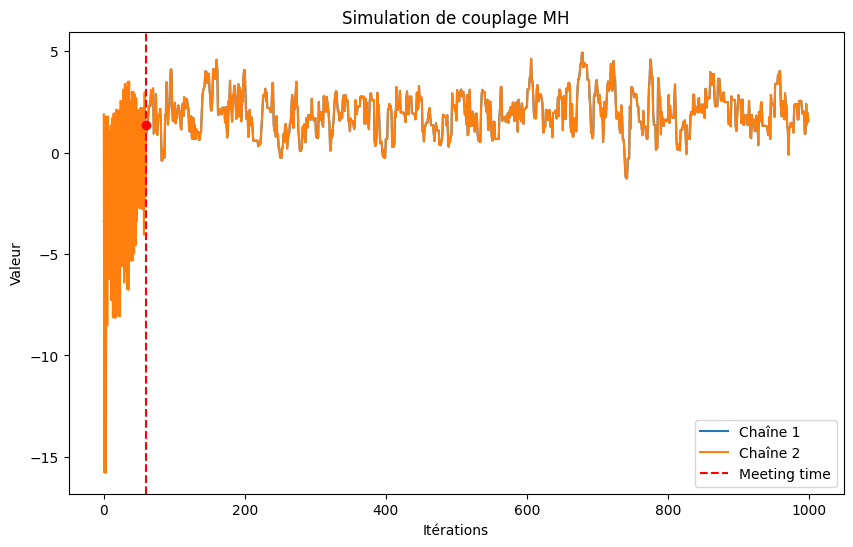

60

In [44]:
simulate_coupling(1000, path, sigmaq)